<a href="https://www.kaggle.com/code/lalit7881/bitcoin-tweets-2025-26?scriptVersionId=301517085" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load
import csv
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/pokeash/bitcoin-tweets-dataset-20252026/bitcoin_tweets_latest.csv


## Import dataset

In [2]:
df = pd.read_csv(
    "/kaggle/input/datasets/pokeash/bitcoin-tweets-dataset-20252026/bitcoin_tweets_latest.csv",
    nrows=5,
    on_bad_lines="skip"
)

print(df.columns.tolist())

['user_name', 'user_location', 'user_description', 'user_created', 'user_followers', 'user_friends', 'user_favourites', 'user_verified', 'date', 'text', 'hashtags', 'source', 'is_retweet']


In [3]:
df.head()

,user_name,user_location,user_description,user_created,user_followers,user_friends,user_favourites,user_verified,date,text,hashtags,source,is_retweet
0,DeSota Wilson,"Atlanta, GA","Biz Consultant, real estate, fintech, startups...",2009-04-26 20:05:09,8534.0,7605,4838,False,2026-02-10 23:59:04,Blue Ridge Bank shares halted by NYSE after #b...,['bitcoin'],Twitter Web App,False
1,Tdlmatias,"London, England","IM Academy : The best #forex, #SelfEducation, ...",2014-11-10 10:50:37,128.0,332,924,False,2026-02-10 23:54:48,"Guys evening, I have read this article about B...",NaN,Twitter Web App,False
2,Crypto is the future,NaN,I will post a lot of buying signals for BTC tr...,2019-09-28 16:48:12,625.0,129,14,False,2026-02-10 23:54:33,$BTC A big chance in a billion! Price: \487264...,"['Bitcoin', 'FX', 'BTC', 'crypto']",dlvr.it,False
3,Alex Kirchmaier 🇦🇹🇸🇪 #FactsSuperspreader,Europa,Co-founder @RENJERJerky | Forbes 30Under30 | I...,2016-02-03 13:15:55,1249.0,1472,10482,False,2026-02-10 23:54:06,This network is secured by 9 508 nodes as of t...,['BTC'],Twitter Web App,False
4,ZerrBenz™ ⚔ ✪ 20732,"Bkk, Thailand",I'm a cat slave 🐱 Interested in Blockchain · T...,2010-01-12 07:00:04,742.0,716,2444,False,2026-02-10 23:53:30,💹 Trade #Crypto on #Binance \n\n📌 Enjoy #Cashb...,"['Crypto', 'Binance', 'Cashback']",Twitter Web App,False


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   user_name         5 non-null      object 
 1   user_location     4 non-null      object 
 2   user_description  5 non-null      object 
 3   user_created      5 non-null      object 
 4   user_followers    5 non-null      float64
 5   user_friends      5 non-null      int64  
 6   user_favourites   5 non-null      int64  
 7   user_verified     5 non-null      bool   
 8   date              5 non-null      object 
 9   text              5 non-null      object 
 10  hashtags          4 non-null      object 
 11  source            5 non-null      object 
 12  is_retweet        5 non-null      bool   
dtypes: bool(2), float64(1), int64(2), object(8)
memory usage: 582.0+ bytes


In [5]:
df.describe()

,user_followers,user_friends,user_favourites
count,5.000000,5.000000,5.000000
mean,2255.600000,2050.800000,3740.400000
std,3532.282308,3146.959914,4187.860886
min,128.000000,129.000000,14.000000
25%,625.000000,332.000000,924.000000
50%,742.000000,716.000000,2444.000000
75%,1249.000000,1472.000000,4838.000000
max,8534.000000,7605.000000,10482.000000


In [6]:
df.isnull().sum()

user_name           0
user_location       1
user_description    0
user_created        0
user_followers      0
user_friends        0
user_favourites     0
user_verified       0
date                0
text                0
hashtags            1
source              0
is_retweet          0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.shape

(5, 13)

In [9]:
df.columns

Index(['user_name', 'user_location', 'user_description', 'user_created',
       'user_followers', 'user_friends', 'user_favourites', 'user_verified',
       'date', 'text', 'hashtags', 'source', 'is_retweet'],
      dtype='object')

In [10]:
df.dtypes

user_name            object
user_location        object
user_description     object
user_created         object
user_followers      float64
user_friends          int64
user_favourites       int64
user_verified          bool
date                 object
text                 object
hashtags             object
source               object
is_retweet             bool
dtype: object

In [11]:
df.nunique()

user_name           5
user_location       4
user_description    5
user_created        5
user_followers      5
user_friends        5
user_favourites     5
user_verified       1
date                5
text                5
hashtags            4
source              2
is_retweet          1
dtype: int64

## Data visualizations

In [12]:
sns.set(style="whitegrid")
plt.figure(figsize=(10,6))

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

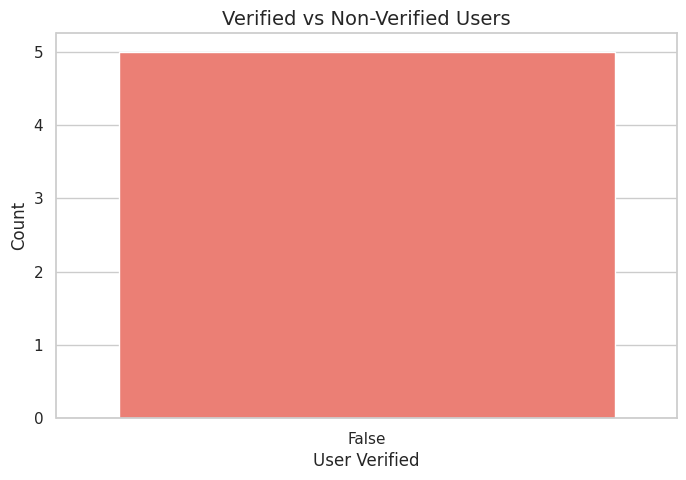

In [13]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="user_verified",
    data=df,
    palette=["#FF6F61", "#6B5B95"]
)

plt.title("Verified vs Non-Verified Users", fontsize=14)
plt.xlabel("User Verified")
plt.ylabel("Count")
plt.show()

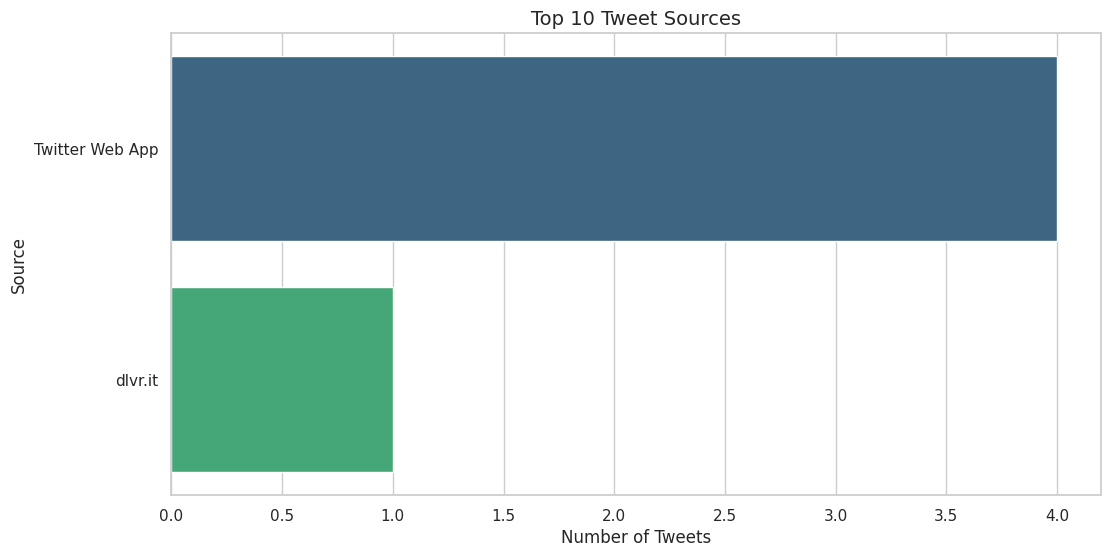

In [14]:
plt.figure(figsize=(12,6))

top_sources = df["source"].value_counts().head(10)

sns.barplot(
    x=top_sources.values,
    y=top_sources.index,
    palette="viridis"
)

plt.title("Top 10 Tweet Sources", fontsize=14)
plt.xlabel("Number of Tweets")
plt.ylabel("Source")
plt.show()

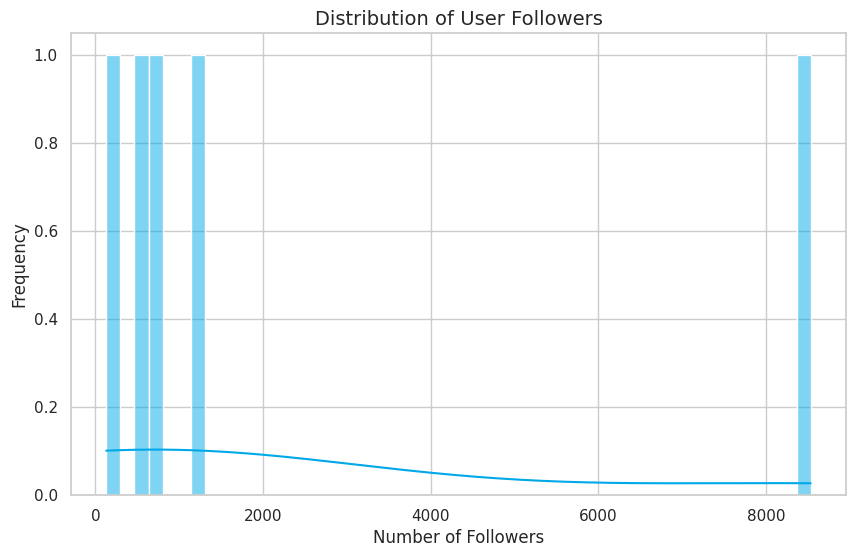

In [15]:
plt.figure(figsize=(10,6))

sns.histplot(
    df["user_followers"],
    bins=50,
    kde=True,
    color="#00A8E8"
)

plt.title("Distribution of User Followers", fontsize=14)
plt.xlabel("Number of Followers")
plt.ylabel("Frequency")
plt.show()

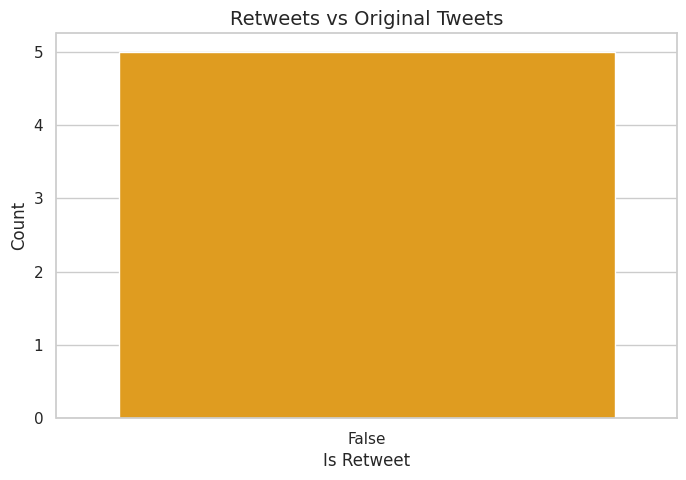

In [16]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="is_retweet",
    data=df,
    palette=["#FFA600", "#58508D"]
)

plt.title("Retweets vs Original Tweets", fontsize=14)
plt.xlabel("Is Retweet")
plt.ylabel("Count")
plt.show()

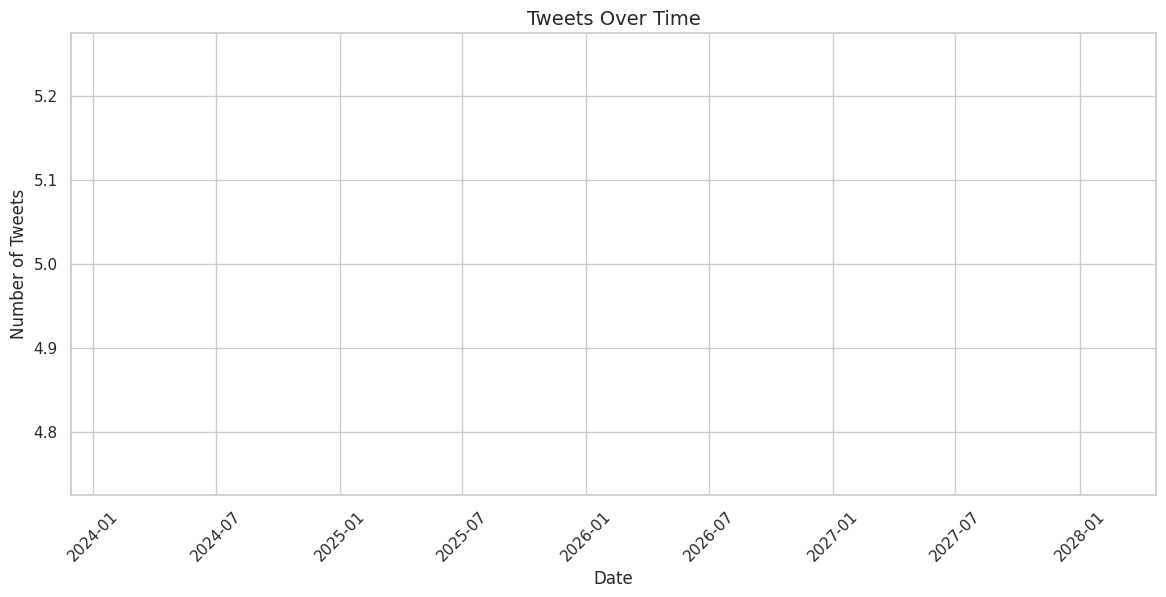

In [17]:
df["date"] = pd.to_datetime(df["date"], errors="coerce")

tweets_per_day = df.groupby(df["date"].dt.date).size()

plt.figure(figsize=(14,6))

tweets_per_day.plot(color="#2ECC71")

plt.title("Tweets Over Time", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Number of Tweets")
plt.xticks(rotation=45)
plt.show()

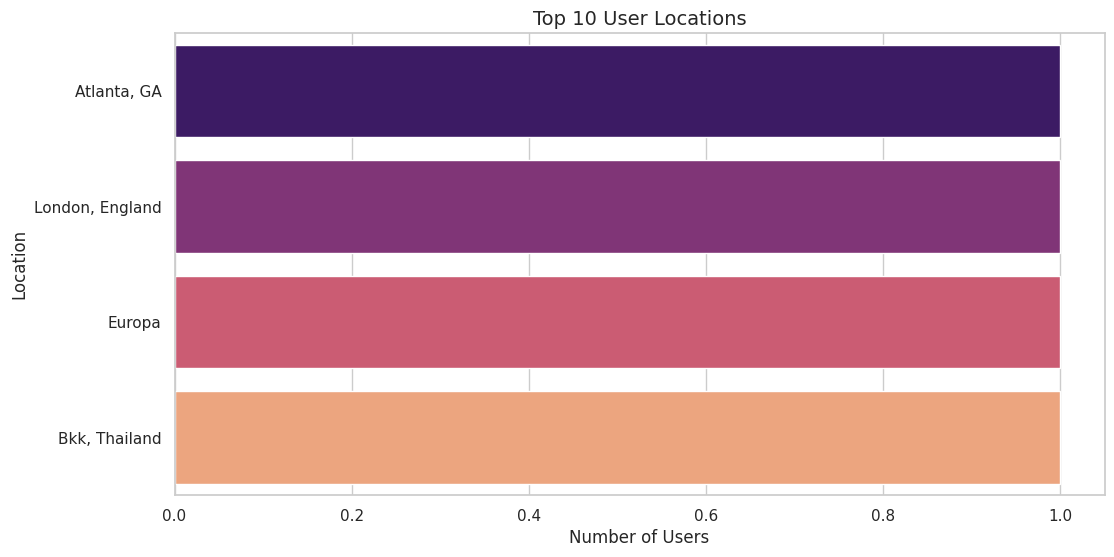

In [18]:
plt.figure(figsize=(12,6))

top_locations = df["user_location"].value_counts().head(10)

sns.barplot(
    x=top_locations.values,
    y=top_locations.index,
    palette="magma"
)

plt.title("Top 10 User Locations", fontsize=14)
plt.xlabel("Number of Users")
plt.ylabel("Location")
plt.show()

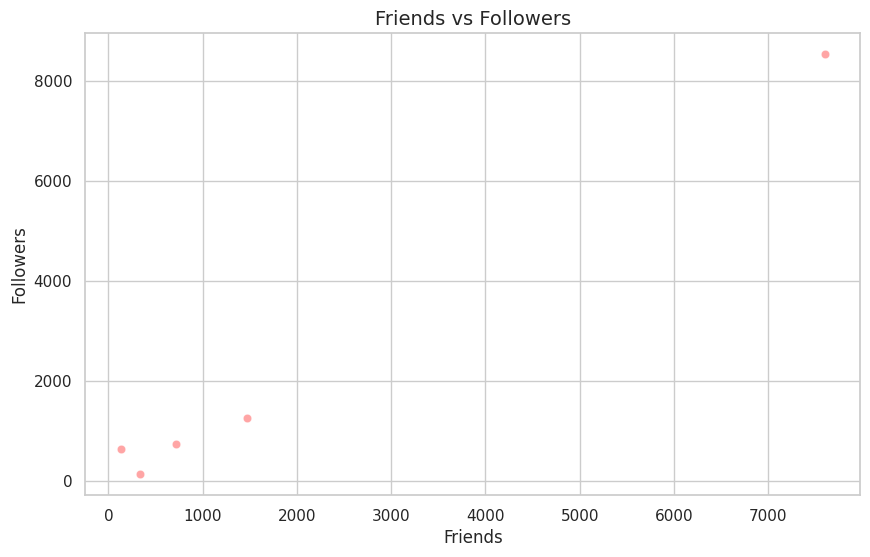

In [19]:
plt.figure(figsize=(10,6))

sample_size = min(5000, len(df))

sns.scatterplot(
    x="user_friends",
    y="user_followers",
    data=df.sample(sample_size),
    color="#FF4C4C",
    alpha=0.5
)

plt.title("Friends vs Followers", fontsize=14)
plt.xlabel("Friends")
plt.ylabel("Followers")
plt.show()

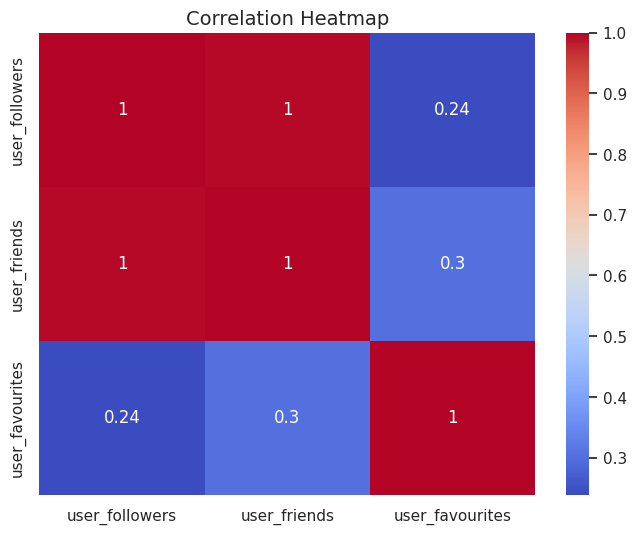

In [20]:
plt.figure(figsize=(8,6))

numeric_cols = df[[
    "user_followers",
    "user_friends",
    "user_favourites"
]]

sns.heatmap(
    numeric_cols.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap", fontsize=14)
plt.show()

## Feature engineering

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

In [22]:
# Basic preprocessing
df.fillna("Unknown", inplace=True)

df["user_followers"] = pd.to_numeric(df["user_followers"], errors="coerce")
df["user_friends"] = pd.to_numeric(df["user_friends"], errors="coerce")
df["user_favourites"] = pd.to_numeric(df["user_favourites"], errors="coerce")

df.fillna(0, inplace=True)

# Create target
median_followers = df["user_followers"].median()
df["high_followers"] = (df["user_followers"] > median_followers).astype(int)

# Convert boolean to int
df["user_verified"] = df["user_verified"].astype(int)

# Features
X = df[["user_friends", "user_favourites", "user_verified"]]
y = df["high_followers"]

print("Dataset size:", len(df))
print("Class distribution:\n", y.value_counts())

# 🔥 SAFE SPLIT (auto-handles small datasets)
if len(df) < 10:
    print("Dataset too small → splitting without stratify")
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.4,
        random_state=42
    )
else:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Model
model = LogisticRegression()
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Dataset size: 5
Class distribution:
 high_followers
0    3
1    2
Name: count, dtype: int64
Dataset too small → splitting without stratify

Accuracy: 0.5

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.50      0.67         2
           1       0.00      0.00      0.00         0

    accuracy                           0.50         2
   macro avg       0.50      0.25      0.33         2
weighted avg       1.00      0.50      0.67         2



## Thank you,,pls upvote!!!!!!!!